<a href="https://colab.research.google.com/github/rolessia/nm/blob/main/Lab13/%D0%9B%D0%A013.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Рак Олеся, Варіант 18, Була присутня на парі

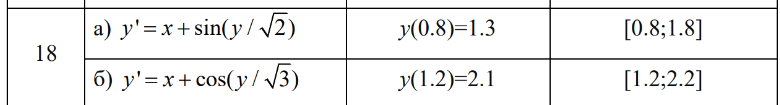

Метод Ейлера

x = [0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8] 
y = [1.3    1.4595 1.6353 1.8269 2.033  2.2521 2.4821 2.7204 2.9643 3.2108
 3.4573]


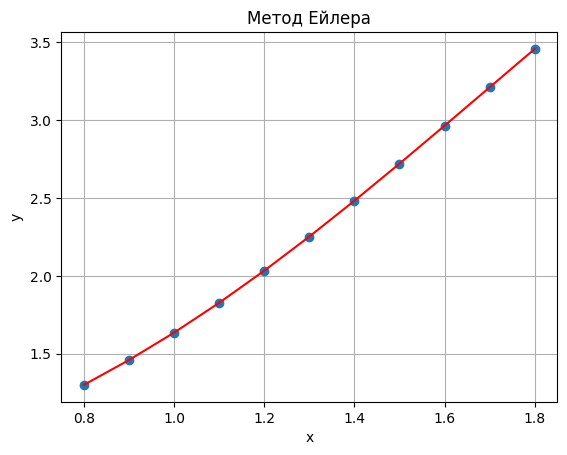

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return x + np.sin(y / np.sqrt(2))

a, b, h, y0 = 0.8, 1.8, 0.1, 1.3

if h <= 0:
    print("Крок h повинен бути позитивним.")
    exit()
if a >= b:
    print("Права межа b повинна бути більшою за ліву межу a.")
    exit()

n = int(round((b - a) / h))

x = np.array([a + i*h for i in range(n + 1)])

y = np.empty(n + 1)
y[0] = y0

for i in range(n):
    y[i + 1] = y[i] + f(x[i], y[i]) * h

y_rounded = np.round(y, 4)
print("x =", x, "\ny =", y_rounded)

plt.plot(x, y, "o", x, y, "red")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Метод Ейлера")
plt.grid(True)
plt.show()

перевірка солв ивп

In [ ]:
from scipy.integrate import solve_ivp

x0 = 0.8
y0 = [1.3]
x_end = 1.8

solution = solve_ivp(
    f,
    [x0, x_end],
    y0,
    t_eval=np.linspace(x0, x_end, 11)
)

print("x =", solution.t)
print("y =", np.round(solution.y[0], 4))

x = [0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8]
y = [1.3    1.4679 1.6523 1.8521 2.0653 2.2898 2.5233 2.7634 3.0075 3.2529
 3.4967]


Метод Ейлера Коші

x = [0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8] 
y = [1.3    1.4677 1.6516 1.8508 2.0638 2.2884 2.5223 2.7626 3.0065 3.2513
 3.4946]


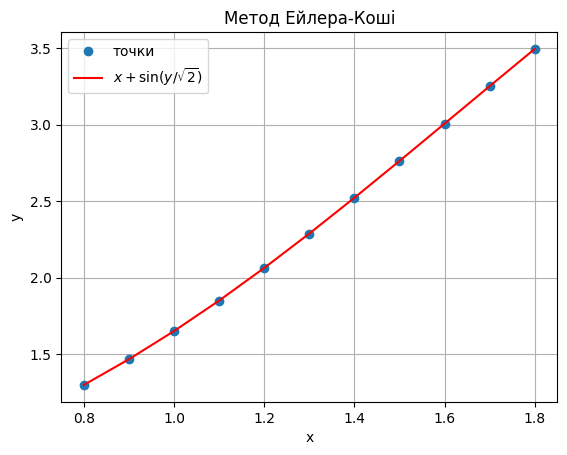

In [ ]:
def f(x, y):
    return x + np.sin(y / np.sqrt(2))

a, b, h, y0 = 0.8, 1.8, 0.1, 1.3

n = int(round((b - a) / h))
x = np.arange(a, b + h/2, h)

y = np.empty(n + 1)
y[0] = y0

for i in range(n):
    y[i + 1] = y[i] + (f(x[i], y[i]) + f(x[i + 1], y[i] + h * f(x[i], y[i]))) * h / 2

y_rounded = np.round(y, 4)

print("x =", x, "\ny =", y_rounded)

# Візуалізація
plt.plot(x, y, "o", x, y, "red")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Метод Ейлера-Коші")
plt.legend(["точки", r"$x + \sin(y / \sqrt{2})$"])
plt.grid()
plt.show()

Розв'язок диф. рівняння

x= [0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8]
y= [1.3    1.4679 1.652  1.8514 2.0646 2.2895 2.5235 2.764  3.008  3.253
 3.4964]


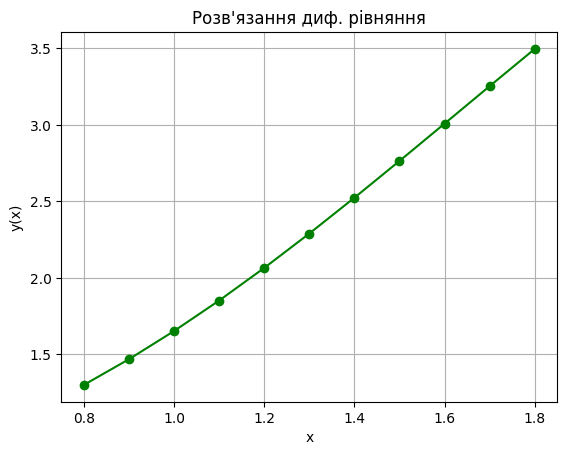

In [ ]:
from scipy.integrate import odeint


def model(y, x):
    return x + np.sin(y / np.sqrt(2))

y0 = 1.3

x = np.array([0.8 + i * 0.1 for i in range(11)])

y = odeint(model, y0, x)

print('x=', np.round(x, 4))
print('y=', np.round(y.flatten(), 4))

plt.plot(x, y, marker='o', color='green')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title("Розв'язання диф. рівняння")
plt.grid()
plt.show()

x= [0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8]
y= [1.3    1.4679 1.6523 1.8521 2.0653 2.2898 2.5233 2.7634 3.0075 3.2529
 3.4967]


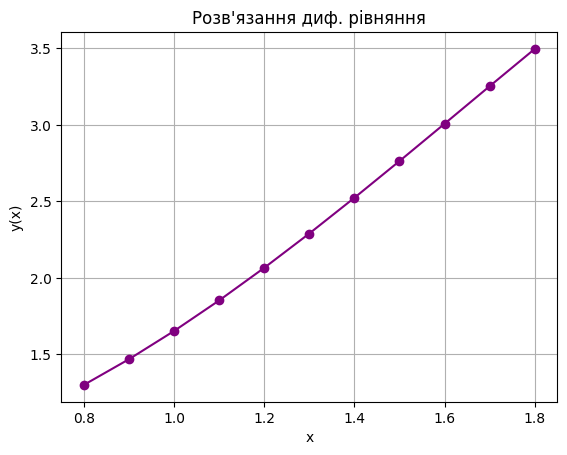

In [ ]:
def model(x, y):
    return x + np.sin(y / np.sqrt(2))

y0 = [1.3]

x = np.linspace(0.8, 1.8, 11)

sol = solve_ivp(model, [0.8, 1.8], y0, t_eval=x)

print('x=', np.round(sol.t, 4))
print('y=', np.round(sol.y[0], 4))

plt.plot(sol.t, sol.y[0], marker='o', color='purple')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title("Розв'язання диф. рівняння")
plt.grid()
plt.show()